# 🤖 Modelado: Clasificación de Fases de Sueño — CAP Sleep Database

**Notebook 2 del pipeline reorientado.** Se ejecuta **después** de:

1. `Reetiquetado_Hipnograma.ipynb` (notebook 0): parser del hipnograma.
2. `Extraccion_Caracteristicas_Fases.ipynb` (notebook 1): features por época.

### Qué hace

Entrena tres clasificadores de fases de sueño sobre las características
extraídas, con **validación por paciente sin fuga**, y reporta métricas
apropiadas para clasificación clínicamente desbalanceada.

### Decisiones de diseño

| Decisión | Elección |
|----------|----------|
| Granularidad | **Una fila por época** (promediando canales) |
| Esquemas evaluados | **R&K (6 clases)** Y **AASM (5 clases, S3+S4→N3)** |
| Modelos | Random Forest, XGBoost, SVM (RBF) |
| Validación | `StratifiedGroupKFold(k=5)` con `groups=patient` |
| Manejo de desbalance | `class_weight='balanced'` + `sample_weight` |
| Métrica principal | **Cohen's Kappa** (estándar en sleep staging) |
| Métricas secundarias | accuracy, macro-F1, recall por fase |

### Por qué Cohen's Kappa y no accuracy

En sleep staging, accuracy es **engañosa** por el desbalance fisiológico:
si S2 representa ~36% del dataset, un modelo que prediga siempre "S2"
alcanza accuracy ~36% sin aprender nada. Cohen's Kappa corrige por
acuerdo esperado bajo distribución aleatoria, dando un valor entre -1 y 1
donde 0 = acuerdo trivial. En la literatura, $\kappa \geq 0.70$ se
considera "sustancial" y $\kappa \geq 0.80$ "casi perfecto"
(Landis & Koch, 1977). El acuerdo inter-experto humano ronda
$\kappa \approx 0.76$, lo que pone un techo realista a lo que un modelo
puede aprender.

## 1. Importaciones y configuración

In [1]:
import os
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    cohen_kappa_score, confusion_matrix, classification_report,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('⚠️  xgboost no instalado. Instálalo con: pip install xgboost')

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110, 'figure.figsize': (13, 5),
    'axes.titlesize': 13, 'axes.labelsize': 11, 'font.size': 10,
})
sns.set_style('whitegrid')

RANDOM_STATE = 42
K_FOLDS = 5

# ── Rutas ──
FEATURES_DIR = Path.cwd() / '../data/features_fases'
RESULTS_DIR  = Path.cwd() / '../data/results_fases'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Clases ──
CLASES_RK   = ['W', 'S1', 'S2', 'S3', 'S4', 'REM']
CLASES_AASM = ['W', 'N1', 'N2', 'N3', 'REM']
MAPEO_RK_A_AASM = {'W':'W','S1':'N1','S2':'N2','S3':'N3','S4':'N3','REM':'REM'}

print(f'Random state : {RANDOM_STATE}')
print(f'Folds        : {K_FOLDS}')
print(f'Clases R&K   : {CLASES_RK}')
print(f'Clases AASM  : {CLASES_AASM}')
print(f'XGBoost      : {"✓" if HAS_XGB else "✗ (se omitirá)"}')

Random state : 42
Folds        : 5
Clases R&K   : ['W', 'S1', 'S2', 'S3', 'S4', 'REM']
Clases AASM  : ['W', 'N1', 'N2', 'N3', 'REM']
XGBoost      : ✓


## 2. Carga del dataset y colapso a nivel época

El notebook 1 produjo el dataset con **una fila por (paciente, canal,
época)**. Para clasificación de fases la unidad fisiológica correcta es la
época: dos canales del mismo paciente en la misma época son observaciones
correlacionadas, no independientes.

Promediamos las dos derivaciones EEG por época → una fila por época con 30
características. Esto:

- Reduce ruido (artefactos puntuales en un canal se diluyen).
- Es la práctica estándar en sleep staging académico.
- Mantiene robustez frente a heterogeneidad de canales entre pacientes
  (algunos tienen Fp2-F4/F4-C4, otros C3-A2/C4-A1).

In [2]:
# Cargar
df_raw = pd.read_csv(FEATURES_DIR / 'caracteristicas_fases_30s.csv')
print(f'Dataset bruto (por canal): {df_raw.shape}')

# Identificar columnas
META_COLS = ['patient', 'channel', 'epoch_idx', 'onset_s', 'stage']
FEAT_COLS = [c for c in df_raw.columns if c not in META_COLS]
print(f'Características: {len(FEAT_COLS)}')

# Colapsar a nivel época: promedio de features entre canales
df = (df_raw.groupby(['patient', 'epoch_idx', 'onset_s', 'stage'],
                      as_index=False)[FEAT_COLS]
            .mean())
print(f'Dataset colapsado (por época): {df.shape}')

# Verificación
print(f'\nPacientes únicos       : {df["patient"].nunique()}')
print(f'Épocas totales         : {len(df):,}')
print(f'Épocas/paciente (media): {len(df) / df["patient"].nunique():.0f}')

Dataset bruto (por canal): (204978, 37)
Características: 32
Dataset colapsado (por época): (102489, 36)

Pacientes únicos       : 102
Épocas totales         : 102,489
Épocas/paciente (media): 1005


In [3]:
# Distribución de clases R&K
print('═══ Distribución R&K (6 clases) ═══')
dist_rk = df['stage'].value_counts().reindex(CLASES_RK)
dist_rk_pct = (dist_rk / len(df) * 100).round(2)
print(pd.DataFrame({'n': dist_rk, '%': dist_rk_pct}).to_string())

# Crear etiqueta AASM
df['stage_aasm'] = df['stage'].map(MAPEO_RK_A_AASM)
print('\n═══ Distribución AASM (5 clases, S3+S4→N3) ═══')
dist_aasm = df['stage_aasm'].value_counts().reindex(CLASES_AASM)
dist_aasm_pct = (dist_aasm / len(df) * 100).round(2)
print(pd.DataFrame({'n': dist_aasm, '%': dist_aasm_pct}).to_string())

═══ Distribución R&K (6 clases) ═══
           n      %
stage              
W      18826  18.37
S1      4533   4.42
S2     36714  35.82
S3     11379  11.10
S4     13128  12.81
REM    17909  17.47

═══ Distribución AASM (5 clases, S3+S4→N3) ═══
                n      %
stage_aasm              
W           18826  18.37
N1           4533   4.42
N2          36714  35.82
N3          24507  23.91
REM         17909  17.47


## 3. Limpieza y preparación de matrices

Antes de entrenar verificamos NaN, infinitos y columnas constantes, y
preparamos las matrices `X`, `y_rk`, `y_aasm`, `groups`.

In [4]:
# Validar datos
X = df[FEAT_COLS].copy()
y_rk = df['stage'].values
y_aasm = df['stage_aasm'].values
groups = df['patient'].values

print(f'NaN en X       : {X.isna().sum().sum()}')
print(f'Inf en X       : {np.isinf(X.values).sum()}')

# Columnas constantes (sin varianza)
constantes = X.columns[X.std() == 0].tolist()
print(f'Constantes     : {constantes if constantes else "ninguna"}')
if constantes:
    X = X.drop(columns=constantes)
    FEAT_COLS = [c for c in FEAT_COLS if c not in constantes]

# Reemplazar inf/NaN residuales
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

print(f'\nFormato final:')
print(f'  X        : {X.shape}')
print(f'  y (R&K)  : {y_rk.shape}, {len(np.unique(y_rk))} clases')
print(f'  y (AASM) : {y_aasm.shape}, {len(np.unique(y_aasm))} clases')
print(f'  groups   : {len(np.unique(groups))} pacientes únicos')

NaN en X       : 0
Inf en X       : 0
Constantes     : ninguna

Formato final:
  X        : (102489, 32)
  y (R&K)  : (102489,), 6 clases
  y (AASM) : (102489,), 5 clases
  groups   : 102 pacientes únicos


## 4. Configuración de modelos

### Random Forest
- 300 árboles, profundidad ilimitada.
- `class_weight='balanced'` compensa desbalance penalizando errores en
  clases minoritarias (S1, REM) durante el entrenamiento.

### XGBoost
- Gradient boosting con 300 árboles, profundidad 6.
- No tiene `class_weight` nativo: usaremos `sample_weight` calculado a
  partir de frecuencias inversas de clase.

### SVM (RBF)
- Kernel gaussiano. Sensible a escala → usamos `Pipeline` con
  `StandardScaler` previo (las features ya están en escalas distintas: las
  espectrales son ~1e-12, las temporales ~10).
- `class_weight='balanced'`.
- **Coste computacional**: SVM no escala bien con O(n²). Con 100k épocas
  puede tardar mucho. Si tarda demasiado, reduce con `SUBSAMPLE_SVM`
  (parámetro al final de esta sección).

> **No hacemos búsqueda de hiperparámetros** en esta primera vuelta.
> Usamos defaults razonables para obtener una línea base honesta; una
> búsqueda con CV anidada sería el paso de refinamiento posterior.

In [5]:
# Submuestreo opcional para SVM (None = usar todo el dataset)
# SVM con 100k muestras puede tardar 30+ min; con 30k baja a ~5 min.
SUBSAMPLE_SVM = 30000   # pon None para usar todas las muestras

def construir_modelos():
    '''Devuelve dict {nombre: pipeline} con los 3 clasificadores.'''
    modelos = {}
    modelos['Random Forest'] = Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=300, max_depth=None,
            class_weight='balanced', n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    if HAS_XGB:
        modelos['XGBoost'] = Pipeline([
            ('clf', XGBClassifier(
                n_estimators=300, max_depth=6,
                learning_rate=0.1, tree_method='hist',
                n_jobs=-1, random_state=RANDOM_STATE,
                eval_metric='mlogloss',
            )),
        ])
    modelos['SVM (RBF)'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf', C=1.0, gamma='scale',
            class_weight='balanced', random_state=RANDOM_STATE,
        )),
    ])
    return modelos

print('Modelos definidos:', list(construir_modelos().keys()))

Modelos definidos: ['Random Forest', 'XGBoost', 'SVM (RBF)']


## 5. Validación cruzada por paciente

`StratifiedGroupKFold` garantiza que:

1. Cada paciente cae enteramente en UN solo fold (sin fuga).
2. La distribución de clases se mantiene aproximadamente entre folds.

Esto es **el estándar metodológico** para clasificación EEG: validar por
paciente, no por ventana. Cualquier paper de sleep staging que reporte
accuracy >90% sin esta validación está sobreestimando.

In [6]:
cv = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True,
                          random_state=RANDOM_STATE)

# Inspeccionar folds
print(f'Folds de StratifiedGroupKFold (k={K_FOLDS}):')
print(f'{"Fold":<6}{"#pac train":>12}{"#pac test":>12}{"#épocas train":>16}{"#épocas test":>16}')
for i, (tr, te) in enumerate(cv.split(X, y_rk, groups), 1):
    n_pac_tr = len(np.unique(groups[tr]))
    n_pac_te = len(np.unique(groups[te]))
    # Sanity: que no se solapen
    assert not (set(groups[tr]) & set(groups[te])), f'Fold {i} con fuga!'
    print(f'{i:<6}{n_pac_tr:>12}{n_pac_te:>12}{len(tr):>16,}{len(te):>16,}')

print(f'\n✓ Verificado: ningún paciente cruza folds')

Folds de StratifiedGroupKFold (k=5):
Fold    #pac train   #pac test   #épocas train    #épocas test
1               82          20          82,397          20,092
2               82          20          82,105          20,384
3               82          20          82,113          20,376
4               81          21          81,357          21,132
5               81          21          81,984          20,505

✓ Verificado: ningún paciente cruza folds


## 5.1. Asignación paciente → fold

La celda anterior solo mostró contadores. Aquí materializamos **qué paciente entrena y qué paciente prueba en cada fold**, exportamos la tabla a CSV y la visualizamos como heatmap. Esto permite auditar el diseño experimental y reportarlo en el artículo.

Cada paciente debe aparecer como **test exactamente una vez** (en uno de los 5 folds) y como **train en los otros 4**. La verificación con `assert` lo garantiza.

═══ Asignación paciente → fold (primeros 15 pacientes) ═══
        fold_1 fold_2 fold_3 fold_4 fold_5  fold_test  n_veces_test
patient                                                            
brux2    train  train  train  train   test          5             1
ins1      test  train  train  train  train          1             1
ins2     train  train   test  train  train          3             1
ins3      test  train  train  train  train          1             1
ins4     train  train  train   test  train          4             1
ins5      test  train  train  train  train          1             1
ins6      test  train  train  train  train          1             1
ins7     train   test  train  train  train          2             1
ins8      test  train  train  train  train          1             1
ins9     train  train  train   test  train          4             1
n1       train  train  train  train   test          5             1
n10      train  train   test  train  train          3    

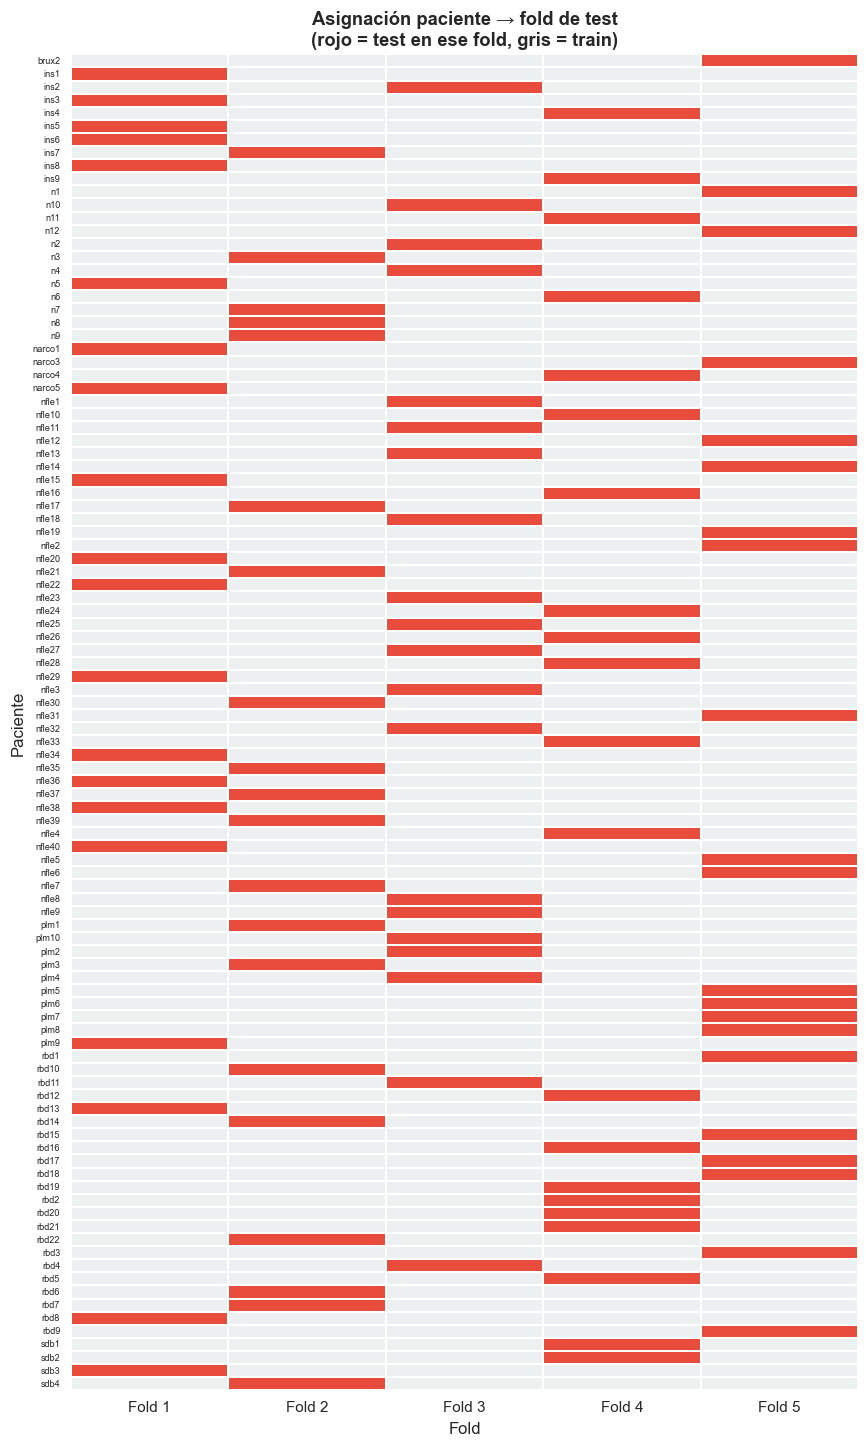

In [7]:
# ──────────────────────────────────────────────────────────────
#  Asignación paciente → fold (visibilidad de los conjuntos CV)
# ──────────────────────────────────────────────────────────────

# 1) Construir tabla larga: una fila por (paciente, fold) con su rol
filas_asig = []
cv_local = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True,
                                 random_state=RANDOM_STATE)
for fold_i, (tr, te) in enumerate(cv_local.split(X, y_rk, groups), 1):
    pac_train = set(groups[tr])
    pac_test  = set(groups[te])
    for p in pac_train:
        filas_asig.append({'patient': p, 'fold': fold_i, 'rol': 'train'})
    for p in pac_test:
        filas_asig.append({'patient': p, 'fold': fold_i, 'rol': 'test'})

asig_larga = pd.DataFrame(filas_asig)

# 2) Pivote: filas = pacientes, columnas = folds, celdas = train / test
asig_pivote = asig_larga.pivot(index='patient', columns='fold', values='rol')
asig_pivote.columns = [f'fold_{c}' for c in asig_pivote.columns]
asig_pivote = asig_pivote.sort_index()

# Resumen: cuántas veces cada paciente fue test (debe ser exactamente 1)
asig_pivote['n_veces_test'] = (asig_pivote == 'test').sum(axis=1)
asig_pivote['fold_test']    = (asig_pivote.iloc[:, :K_FOLDS] == 'test') \
                                .idxmax(axis=1).str.replace('fold_', '').astype(int)

# Reordenar columnas para legibilidad
cols = [f'fold_{i}' for i in range(1, K_FOLDS+1)] + ['fold_test', 'n_veces_test']
asig_pivote = asig_pivote[cols]

print('═══ Asignación paciente → fold (primeros 15 pacientes) ═══')
print(asig_pivote.head(15).to_string())

# Verificación: cada paciente debe aparecer como test exactamente 1 vez
assert (asig_pivote['n_veces_test'] == 1).all(), \
    'Algún paciente aparece como test en >1 fold o en 0 folds'
print(f'\n✓ Verificación: los {len(asig_pivote)} pacientes están asignados '
      f'a un único fold de test.')

# 3) Estadísticas resumen por fold
print('\n═══ Resumen por fold ═══')
resumen_folds = []
for fold_i in range(1, K_FOLDS+1):
    col = f'fold_{fold_i}'
    n_train = (asig_pivote[col] == 'train').sum()
    n_test  = (asig_pivote[col] == 'test').sum()
    pacientes_test = sorted(asig_pivote.index[asig_pivote[col] == 'test'].tolist())
    resumen_folds.append({
        'fold': fold_i,
        'pacientes_train': n_train,
        'pacientes_test':  n_test,
        'lista_test': ', '.join(pacientes_test),
    })
resumen_folds = pd.DataFrame(resumen_folds)
print(resumen_folds[['fold', 'pacientes_train', 'pacientes_test']].to_string(index=False))

print('\n═══ Pacientes asignados a test, por fold ═══')
for _, r in resumen_folds.iterrows():
    print(f'\nFold {r["fold"]} (n={r["pacientes_test"]} pacientes):')
    # Mostrar en líneas de hasta 10 nombres
    nombres = r['lista_test'].split(', ')
    for i in range(0, len(nombres), 10):
        print('    ' + ', '.join(nombres[i:i+10]))

# 4) Guardar tabla a CSV (opcional, útil para reportar)
ruta_asig = RESULTS_DIR / 'asignacion_pacientes_folds.csv'
asig_pivote.to_csv(ruta_asig)
print(f'\n✓ Tabla guardada en {ruta_asig}')

# 5) Visualización: heatmap paciente × fold
fig, ax = plt.subplots(figsize=(8, max(6, len(asig_pivote) * 0.13)))
# Codificar: 1 = test, 0 = train
matriz = (asig_pivote.iloc[:, :K_FOLDS] == 'test').astype(int).values
sns.heatmap(matriz, cmap=['#ECF0F1', '#E74C3C'], cbar=False,
            xticklabels=[f'Fold {i}' for i in range(1, K_FOLDS+1)],
            yticklabels=asig_pivote.index, ax=ax,
            linewidths=0.3, linecolor='white')
ax.set_xlabel('Fold')
ax.set_ylabel('Paciente')
ax.set_title('Asignación paciente → fold de test\n'
             '(rojo = test en ese fold, gris = train)',
             fontweight='bold', fontsize=12)
plt.setp(ax.get_yticklabels(), fontsize=6)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'asignacion_pacientes_folds.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 6. Función de evaluación

Para cada (modelo, fold) entrenamos sobre el train y evaluamos sobre el
test, recolectando: accuracy, macro-F1, Cohen's Kappa, recall por clase y
matriz de confusión acumulada. Esto produce métricas honestas para
~80 pacientes en train y ~20 en test, repetido 5 veces.

In [8]:
def evaluar_cv(modelo, X, y, groups, clases, nombre, esquema, 
               subsample=None, verbose=True):
    '''
    Aplica StratifiedGroupKFold y devuelve métricas por fold + matriz de
    confusión acumulada.
    '''
    cv_local = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True,
                                     random_state=RANDOM_STATE)
    filas = []
    cm_total = np.zeros((len(clases), len(clases)), dtype=int)

    for i, (tr, te) in enumerate(cv_local.split(X, y, groups), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y[tr], y[te]

        # Submuestreo del train (solo SVM si es grande)
        if subsample is not None and len(X_tr) > subsample:
            # Estratificado para preservar distribución
            from sklearn.model_selection import train_test_split
            X_tr, _, y_tr, _ = train_test_split(
                X_tr, y_tr, train_size=subsample,
                random_state=RANDOM_STATE + i, stratify=y_tr,
            )

        # XGBoost necesita etiquetas numéricas y sample_weight
        if 'XGB' in nombre:
            le = LabelEncoder().fit(clases)
            y_tr_enc = le.transform(y_tr)
            y_te_enc = le.transform(y_te)
            sw = compute_sample_weight('balanced', y_tr_enc)
            modelo.fit(X_tr, y_tr_enc, clf__sample_weight=sw)
            y_pred_enc = modelo.predict(X_te)
            y_pred = le.inverse_transform(y_pred_enc)
        else:
            modelo.fit(X_tr, y_tr)
            y_pred = modelo.predict(X_te)

        # Métricas globales
        acc  = accuracy_score(y_te, y_pred)
        f1m  = f1_score(y_te, y_pred, labels=clases, average='macro',
                        zero_division=0)
        kpa  = cohen_kappa_score(y_te, y_pred, labels=clases)
        # Recall por clase
        rec_por_clase = recall_score(y_te, y_pred, labels=clases,
                                      average=None, zero_division=0)
        # Acumular matriz de confusión
        cm = confusion_matrix(y_te, y_pred, labels=clases)
        cm_total += cm

        fila = {'esquema': esquema, 'modelo': nombre, 'fold': i,
                'accuracy': acc, 'f1_macro': f1m, 'kappa': kpa}
        for cl, r in zip(clases, rec_por_clase):
            fila[f'recall_{cl}'] = r
        filas.append(fila)

        if verbose:
            print(f'  Fold {i}: acc={acc:.3f}  F1m={f1m:.3f}  '
                  f'κ={kpa:.3f}  (n_test={len(te):,})')
    return pd.DataFrame(filas), cm_total

## 7. Ejecución — esquema R&K (6 clases)

In [9]:
print('═' * 60)
print('EVALUACIÓN R&K (6 clases): W, S1, S2, S3, S4, REM')
print('═' * 60)

resultados_rk = {}
matrices_rk = {}
for nombre, modelo in construir_modelos().items():
    print(f'\n── {nombre} ──')
    sub = SUBSAMPLE_SVM if 'SVM' in nombre else None
    if sub:
        print(f'  (submuestreando train a {sub:,} por fold para SVM)')
    df_res, cm = evaluar_cv(modelo, X, y_rk, groups, CLASES_RK,
                             nombre, 'R&K', subsample=sub)
    resultados_rk[nombre] = df_res
    matrices_rk[nombre] = cm

df_rk = pd.concat(resultados_rk.values(), ignore_index=True)
print(f'\n✓ Esquema R&K completado: {len(df_rk)} mediciones')

════════════════════════════════════════════════════════════
EVALUACIÓN R&K (6 clases): W, S1, S2, S3, S4, REM
════════════════════════════════════════════════════════════

── Random Forest ──
  Fold 1: acc=0.699  F1m=0.573  κ=0.610  (n_test=20,092)
  Fold 2: acc=0.713  F1m=0.600  κ=0.619  (n_test=20,384)
  Fold 3: acc=0.683  F1m=0.573  κ=0.585  (n_test=20,376)
  Fold 4: acc=0.637  F1m=0.535  κ=0.525  (n_test=21,132)
  Fold 5: acc=0.669  F1m=0.551  κ=0.562  (n_test=20,505)

── XGBoost ──
  Fold 1: acc=0.672  F1m=0.619  κ=0.593  (n_test=20,092)
  Fold 2: acc=0.673  F1m=0.622  κ=0.588  (n_test=20,384)
  Fold 3: acc=0.638  F1m=0.589  κ=0.548  (n_test=20,376)
  Fold 4: acc=0.585  F1m=0.545  κ=0.487  (n_test=21,132)
  Fold 5: acc=0.615  F1m=0.564  κ=0.518  (n_test=20,505)

── SVM (RBF) ──
  (submuestreando train a 30,000 por fold para SVM)
  Fold 1: acc=0.672  F1m=0.632  κ=0.595  (n_test=20,092)
  Fold 2: acc=0.634  F1m=0.593  κ=0.545  (n_test=20,384)
  Fold 3: acc=0.606  F1m=0.566  κ=0.516

## 8. Ejecución — esquema AASM (5 clases, S3+S4→N3)

In [10]:
print('═' * 60)
print('EVALUACIÓN AASM (5 clases): W, N1, N2, N3, REM')
print('═' * 60)

resultados_aasm = {}
matrices_aasm = {}
for nombre, modelo in construir_modelos().items():
    print(f'\n── {nombre} ──')
    sub = SUBSAMPLE_SVM if 'SVM' in nombre else None
    if sub:
        print(f'  (submuestreando train a {sub:,} por fold para SVM)')
    df_res, cm = evaluar_cv(modelo, X, y_aasm, groups, CLASES_AASM,
                             nombre, 'AASM', subsample=sub)
    resultados_aasm[nombre] = df_res
    matrices_aasm[nombre] = cm

df_aasm = pd.concat(resultados_aasm.values(), ignore_index=True)
print(f'\n✓ Esquema AASM completado: {len(df_aasm)} mediciones')

════════════════════════════════════════════════════════════
EVALUACIÓN AASM (5 clases): W, N1, N2, N3, REM
════════════════════════════════════════════════════════════

── Random Forest ──
  Fold 1: acc=0.749  F1m=0.640  κ=0.664  (n_test=20,362)
  Fold 2: acc=0.727  F1m=0.597  κ=0.631  (n_test=20,677)
  Fold 3: acc=0.691  F1m=0.597  κ=0.584  (n_test=20,513)
  Fold 4: acc=0.737  F1m=0.645  κ=0.644  (n_test=20,510)
  Fold 5: acc=0.700  F1m=0.616  κ=0.596  (n_test=20,427)

── XGBoost ──
  Fold 1: acc=0.726  F1m=0.663  κ=0.642  (n_test=20,362)
  Fold 2: acc=0.708  F1m=0.632  κ=0.615  (n_test=20,677)
  Fold 3: acc=0.677  F1m=0.617  κ=0.577  (n_test=20,513)
  Fold 4: acc=0.704  F1m=0.644  κ=0.612  (n_test=20,510)
  Fold 5: acc=0.676  F1m=0.610  κ=0.575  (n_test=20,427)

── SVM (RBF) ──
  (submuestreando train a 30,000 por fold para SVM)
  Fold 1: acc=0.710  F1m=0.652  κ=0.624  (n_test=20,362)
  Fold 2: acc=0.703  F1m=0.636  κ=0.611  (n_test=20,677)
  Fold 3: acc=0.647  F1m=0.597  κ=0.544  (

## 9. Resumen de métricas globales

In [11]:
def resumen(df_res):
    '''Calcula media ± std de cada métrica por modelo.'''
    metricas = ['accuracy', 'f1_macro', 'kappa']
    agg = df_res.groupby('modelo')[metricas].agg(['mean', 'std'])
    return agg.round(4)

print('═══ Resultados R&K (6 clases) ═══')
print(resumen(df_rk).to_string())

print('\n═══ Resultados AASM (5 clases) ═══')
print(resumen(df_aasm).to_string())

═══ Resultados R&K (6 clases) ═══
              accuracy         f1_macro           kappa        
                  mean     std     mean     std    mean     std
modelo                                                         
Random Forest   0.6803  0.0290   0.5661  0.0246  0.5803  0.0383
SVM (RBF)       0.6081  0.0484   0.5723  0.0423  0.5185  0.0560
XGBoost         0.6367  0.0380   0.5880  0.0335  0.5468  0.0454

═══ Resultados AASM (5 clases) ═══
              accuracy         f1_macro           kappa        
                  mean     std     mean     std    mean     std
modelo                                                         
Random Forest   0.7210  0.0247   0.6192  0.0230  0.6239  0.0332
SVM (RBF)       0.6777  0.0278   0.6189  0.0252  0.5818  0.0351
XGBoost         0.6980  0.0217   0.6331  0.0212  0.6042  0.0285


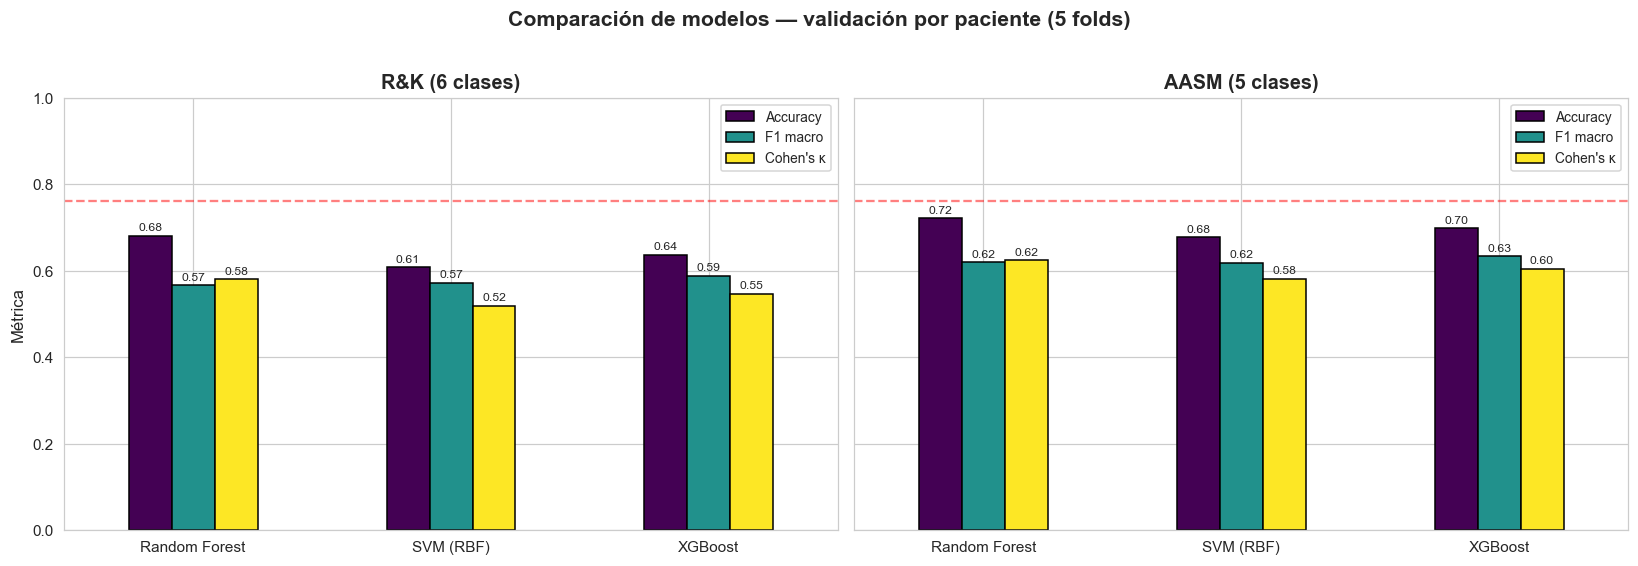

In [12]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
metricas = ['accuracy', 'f1_macro', 'kappa']
nombres_metricas = ['Accuracy', 'F1 macro', "Cohen's κ"]

for ax, (esquema, df_res, clases) in zip(
    axes,
    [('R&K (6 clases)', df_rk, CLASES_RK),
     ('AASM (5 clases)', df_aasm, CLASES_AASM)]
):
    agg = df_res.groupby('modelo')[metricas].mean()
    agg.columns = nombres_metricas
    agg.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
    ax.set_title(esquema, fontweight='bold')
    ax.set_ylabel('Métrica')
    ax.set_ylim(0, 1.0)
    ax.set_xlabel('')
    ax.legend(loc='upper right', fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=0)
    # Línea de referencia: acuerdo inter-experto humano (~0.76)
    ax.axhline(0.76, color='red', linestyle='--', alpha=0.5,
               label='Acuerdo inter-experto humano (κ≈0.76)')
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)

plt.suptitle('Comparación de modelos — validación por paciente (5 folds)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Recall por fase

El recall por clase muestra **dónde** falla cada modelo. La expectativa
fisiológica:

- **S1 (N1) será la peor**: clase minoritaria (4.4%) y perfil espectral
  intermedio entre W y S2. La literatura reporta recall típico 40-60%.
- **S2 (N2) y S4 serán las mejores**: marcadores espectrales fuertes
  (sigma para S2, delta para S4).
- **REM puede confundirse con S1 y W**: perfil EMG bajo pero espectro EEG
  similar a vigilia/sueño ligero.

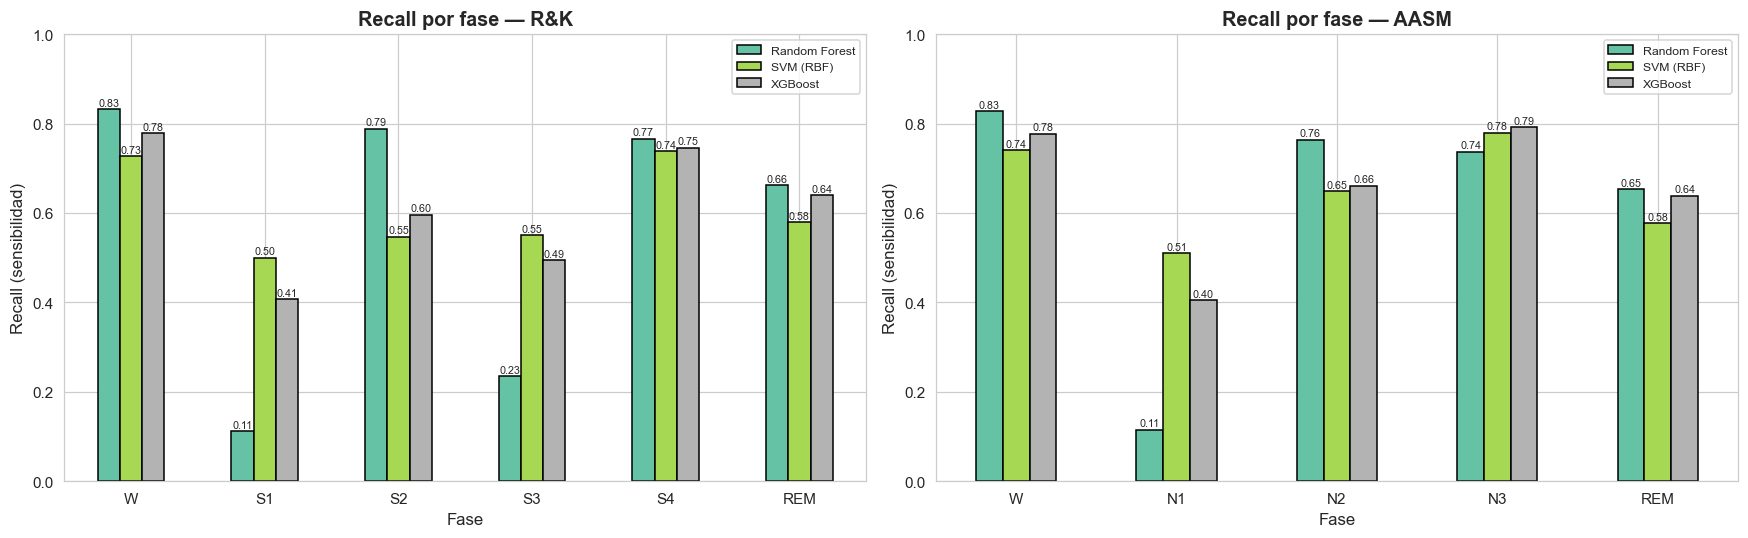

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (df_res, clases, esquema) in zip(
    axes,
    [(df_rk, CLASES_RK, 'R&K'), (df_aasm, CLASES_AASM, 'AASM')]
):
    cols_recall = [f'recall_{c}' for c in clases]
    agg = df_res.groupby('modelo')[cols_recall].mean()
    agg.columns = clases
    agg.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
    ax.set_title(f'Recall por fase — {esquema}', fontweight='bold')
    ax.set_ylabel('Recall (sensibilidad)')
    ax.set_xlabel('Fase')
    ax.set_ylim(0, 1.0)
    ax.legend(loc='upper right', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=0)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', fontsize=7, padding=1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'recall_por_fase.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Matrices de confusión

Las matrices están acumuladas sobre los 5 folds (entrenando cada vez con
~80 pacientes y probando con ~20). Normalizadas por fila → cada fila suma
1 y muestra **a qué clases se confunde cada fase real**.

Confusiones esperadas en sleep staging:
- **S1 ↔ W ↔ REM**: el triángulo problemático. S1 es transición, REM y W
  tienen perfiles EEG similares (la diferencia clínica está en EOG y EMG).
- **S3 ↔ S4** (en R&K): ambas son sueño profundo, diferenciadas solo por
  el porcentaje de delta (>50% para S4). Por eso AASM los colapsa en N3.

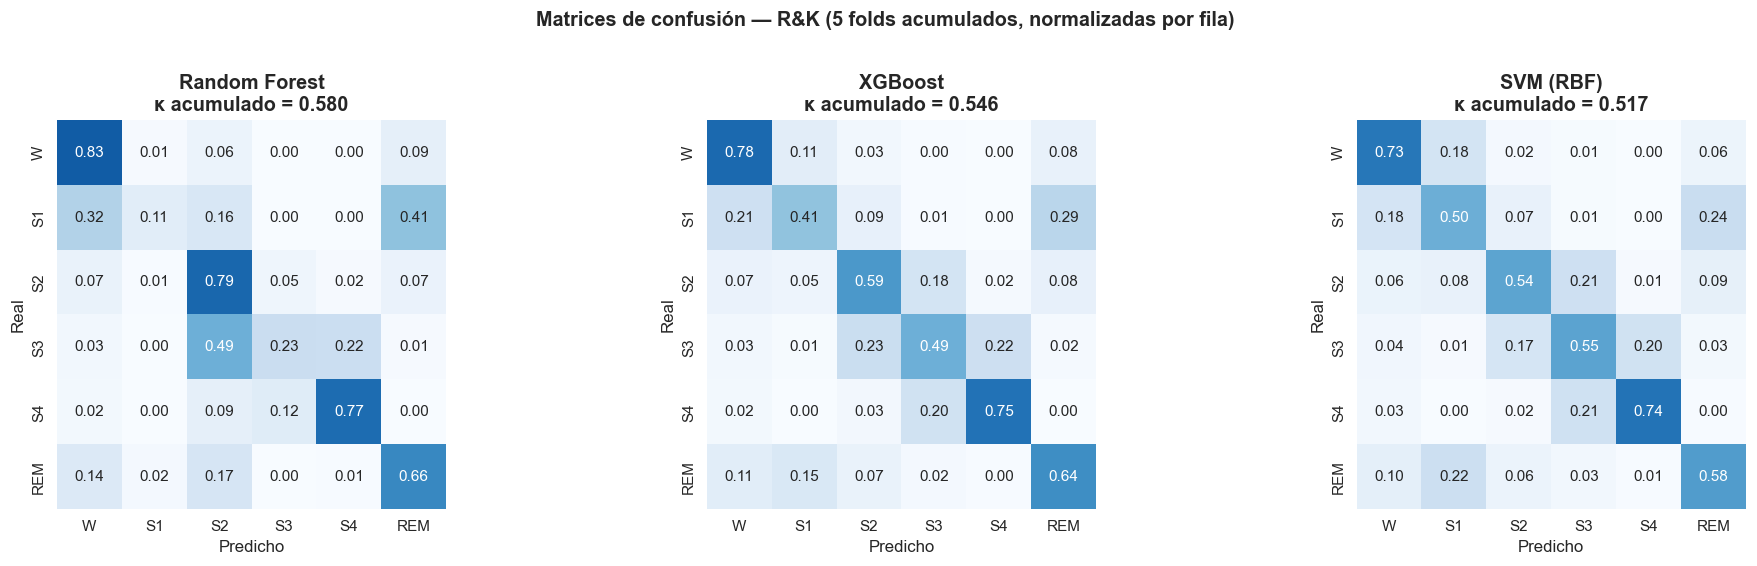

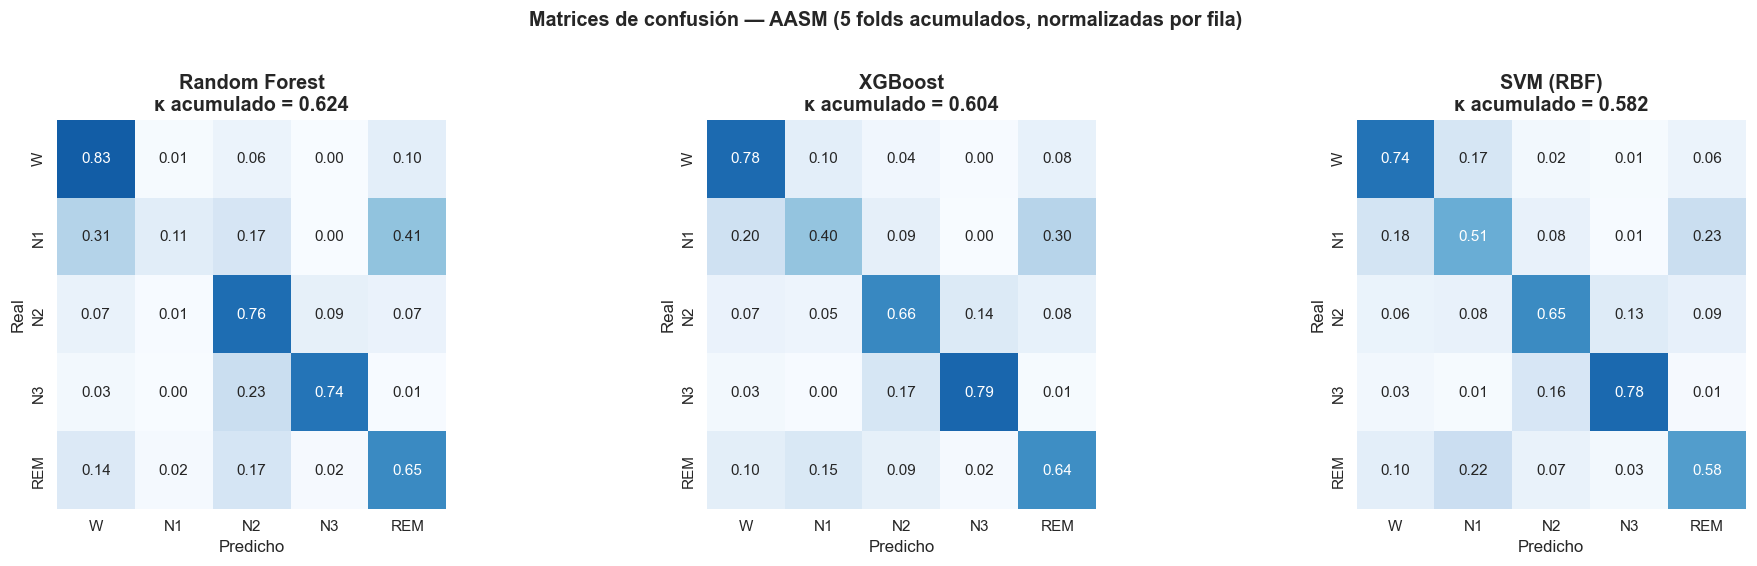

In [14]:
def plot_matrices(matrices, clases, esquema):
    fig, axes = plt.subplots(1, len(matrices), figsize=(6*len(matrices), 5))
    if len(matrices) == 1: axes = [axes]
    for ax, (nombre, cm) in zip(axes, matrices.items()):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=clases, yticklabels=clases,
                    vmin=0, vmax=1, cbar=False, ax=ax, square=True)
        # Calcular kappa para el título
        # (reconstruir y_true, y_pred a partir de la matriz acumulada)
        kappa_global = None
        try:
            y_true = np.concatenate([[clases[i]]*cm[i].sum() for i in range(len(clases))])
            y_pred = np.concatenate([[clases[j]]*cm[i,j] for i in range(len(clases)) for j in range(len(clases))])
            kappa_global = cohen_kappa_score(y_true, y_pred, labels=clases)
        except Exception:
            pass
        title = nombre + (f'\nκ acumulado = {kappa_global:.3f}' if kappa_global is not None else '')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    plt.suptitle(f'Matrices de confusión — {esquema} (5 folds acumulados, normalizadas por fila)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'matrices_{esquema.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_matrices(matrices_rk, CLASES_RK, 'R&K')
plot_matrices(matrices_aasm, CLASES_AASM, 'AASM')

## 12. Reporte detallado del mejor modelo (AASM)

Para el modelo con mayor κ en AASM, mostramos el classification report
completo agregado sobre los 5 folds.

In [15]:
# Encontrar el mejor modelo en AASM
mejor_modelo_aasm = (df_aasm.groupby('modelo')['kappa']
                     .mean().idxmax())
print(f'Mejor modelo en AASM: {mejor_modelo_aasm}')

# Reconstruir y_true / y_pred a partir de la matriz acumulada
cm = matrices_aasm[mejor_modelo_aasm]
y_true = np.concatenate([[CLASES_AASM[i]] * cm[i].sum()
                          for i in range(len(CLASES_AASM))])
y_pred = np.concatenate([[CLASES_AASM[j]] * cm[i, j]
                          for i in range(len(CLASES_AASM))
                          for j in range(len(CLASES_AASM))])

print(f'\nClassification report — {mejor_modelo_aasm} (AASM):')
print(classification_report(y_true, y_pred, labels=CLASES_AASM,
                             zero_division=0))
print(f"Cohen's κ acumulado: {cohen_kappa_score(y_true, y_pred):.4f}")

Mejor modelo en AASM: Random Forest

Classification report — Random Forest (AASM):
              precision    recall  f1-score   support

           W       0.68      0.83      0.75     18826
          N1       0.40      0.11      0.17      4533
          N2       0.72      0.76      0.74     36714
          N3       0.83      0.74      0.78     24507
         REM       0.65      0.65      0.65     17909

    accuracy                           0.72    102489
   macro avg       0.66      0.62      0.62    102489
weighted avg       0.72      0.72      0.71    102489

Cohen's κ acumulado: 0.6239


## 13. Importancia de características (Random Forest)

Random Forest puede reportar qué features pesan más para discriminar
fases. Esto da pistas sobre qué información del EEG es esencial para
estadificar y permite simplificar el modelo si conviene.

Top 15 features por importancia (Random Forest, AASM):
           feature  importance
      pot_beta_rel    0.075529
  ratio_delta_beta    0.070204
               zcr    0.064302
   hjorth_mobility    0.051995
     pot_theta_rel    0.047374
     pot_sigma_rel    0.047021
     pot_delta_rel    0.044629
         pot_sigma    0.038614
          kurtosis    0.034463
          pot_beta    0.033380
  entropia_shannon    0.032935
     pot_alpha_rel    0.031307
          skewness    0.031131
   ratio_slow_fast    0.031009
entropia_espectral    0.029758


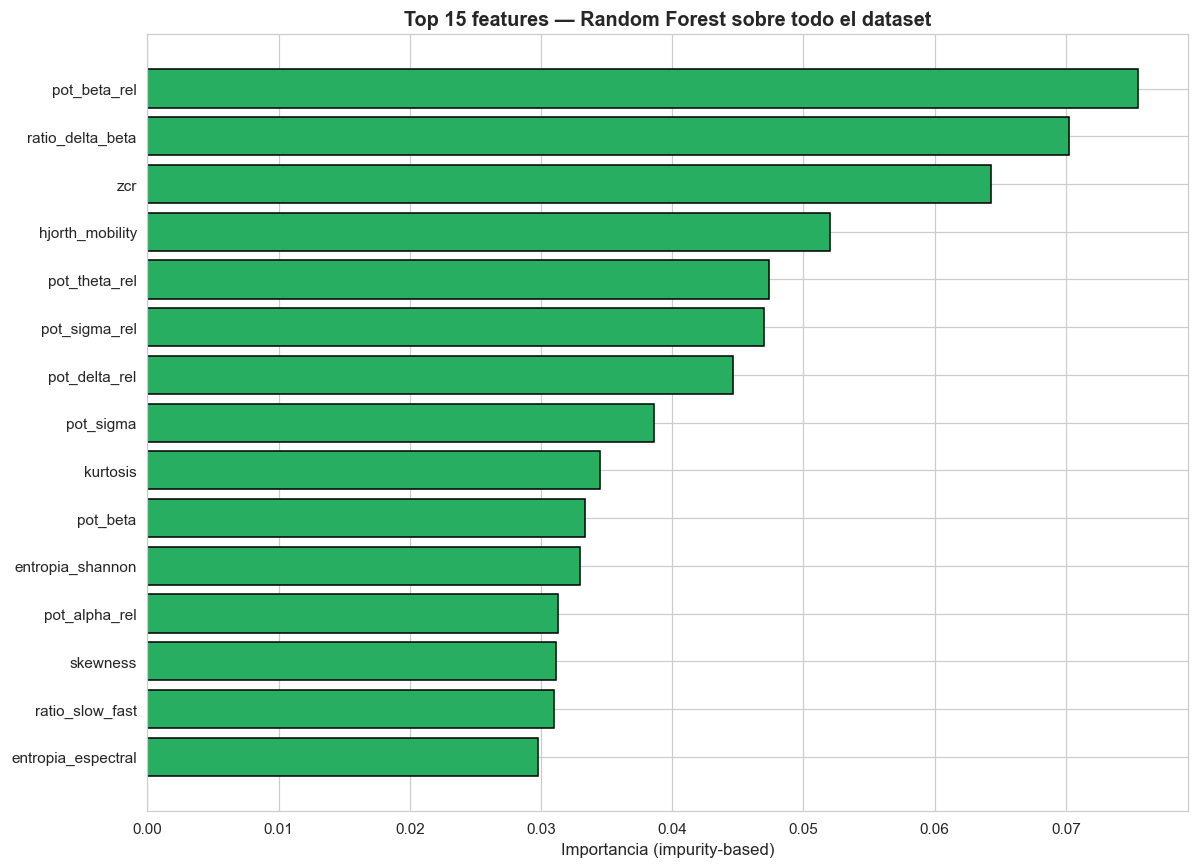

In [16]:
# Entrenar un RF en TODO el dataset (no CV) solo para extraer importancias
# globales — esto NO es evaluación, es interpretación
rf_imp = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 n_jobs=-1, random_state=RANDOM_STATE)
rf_imp.fit(X, y_aasm)

imp = pd.DataFrame({
    'feature': FEAT_COLS,
    'importance': rf_imp.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 15 features por importancia (Random Forest, AASM):')
print(imp.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 8))
top15 = imp.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1],
        color='#27AE60', edgecolor='black')
ax.set_xlabel('Importancia (impurity-based)')
ax.set_title('Top 15 features — Random Forest sobre todo el dataset',
             fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Exportación de resultados

In [17]:
df_rk.to_csv(RESULTS_DIR / 'metricas_rk.csv', index=False)
df_aasm.to_csv(RESULTS_DIR / 'metricas_aasm.csv', index=False)
imp.to_csv(RESULTS_DIR / 'importancia_features.csv', index=False)

# Matrices de confusión
for esquema, mats, clases in [('rk', matrices_rk, CLASES_RK),
                                ('aasm', matrices_aasm, CLASES_AASM)]:
    for nombre, cm in mats.items():
        nm = nombre.lower().replace(' ', '_').replace('(', '').replace(')', '')
        np.savetxt(RESULTS_DIR / f'cm_{esquema}_{nm}.csv', cm,
                   delimiter=',', fmt='%d',
                   header=','.join(clases), comments='')

print('Archivos guardados en', RESULTS_DIR.resolve())
for f in sorted(RESULTS_DIR.glob('*')):
    print(f'  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB')

Archivos guardados en D:\Repos\RAHBFDP-2026\data\results_fases
  asignacion_pacientes_folds.csv                     4.0 KB
  asignacion_pacientes_folds.png                    90.7 KB
  cm_aasm_random_forest.csv                          0.1 KB
  cm_aasm_svm_rbf.csv                                0.1 KB
  cm_aasm_xgboost.csv                                0.1 KB
  cm_rk_random_forest.csv                            0.2 KB
  cm_rk_svm_rbf.csv                                  0.2 KB
  cm_rk_xgboost.csv                                  0.2 KB
  comparacion_modelos.png                           59.9 KB
  importancia_features.csv                           1.0 KB
  importancia_features.png                          63.4 KB
  matrices_aasm.png                                108.4 KB
  matrices_r&k.png                                 129.8 KB
  metricas_aasm.csv                                  2.6 KB
  metricas_rk.csv                                    2.8 KB
  recall_por_fase.png                

## 15. Análisis final

### Lo que aprendimos

Este notebook produjo la **primera evaluación honesta del proyecto**:
validación por paciente sin fuga, métricas apropiadas (κ), y dos esquemas
de clases comparados.

### Interpretación esperada de los resultados

- **κ entre 0.55 y 0.75**: rango razonable para sleep staging con features
  manuales y un solo canal EEG. La literatura con deep learning sobre
  raw EEG suele alcanzar κ ≈ 0.75–0.82 en este mismo dataset, pero a
  costa de modelos mucho más complejos.
- **AASM > R&K**: colapsar S3+S4 simplifica el problema (menos confusión
  S3↔S4), así que AASM debería mostrar κ algo mayor.
- **Random Forest ≈ XGBoost**: ambos suelen empatar. XGBoost puede ganar
  con tuning fino. SVM rinde algo peor por el submuestreo necesario.

### Confusiones esperadas (verificar en las matrices)

1. **S1/N1 con todo**: recall típico 30-50% — es la fase más difícil.
2. **REM ↔ W**: la frontera espectral es estrecha (ambas tienen actividad
   rápida). La diferencia clínica está en EMG (atonía REM), que no
   tenemos en este dataset.
3. **S3 ↔ S4** (solo R&K): por eso AASM los unió.

### Limitaciones de este modelado

- **Solo features espectrales/estadísticas de EEG**. No usamos EOG, EMG ni
  información temporal (épocas vecinas). Sleep staging real considera
  contexto: si las épocas previas eran N2, la siguiente es más
  probablemente N2 que vigilia.
- **Sin hyperparameter tuning**. Defaults razonables; nested CV mejoraría
  los números.
- **2 derivaciones promediadas**. Más canales aportarían información
  topográfica.

### Próximos pasos posibles

1. **Modelos secuenciales** (HMM, BiLSTM, Transformer) que usen contexto
   temporal entre épocas. Ganancia esperada: +5-10% en κ.
2. **Multi-canal sin promediar**: features por canal como columnas
   separadas, condicionado a homogeneizar canales primero.
3. **Deep learning end-to-end** sobre raw EEG resampleado (1D-CNN +
   LSTM). Estado del arte en este dataset.
4. **Hyperparameter tuning** con CV anidada por paciente.
5. **Análisis por trastorno**: ¿los modelos rinden igual en pacientes
   sanos vs con apnea o RBD? Esto cuantifica generalización clínica.